<a href="https://colab.research.google.com/github/asheta66/Machine-Learning-2024/blob/main/Diabeties/DT_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Pierre Gustave
# Logistic Regression model

import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
# drive.mount('/content/drive')


# Load Syhlet dataset
col_names =['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia',
    'Genital Thrush', 'visual blurring',  'Itching','irritability',
    'delay healing','partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity', 'class']

# path = 'drive/My Drive/data_mining_files/'
syhlet_df = pd.read_csv( 'syhlet_diabetes.csv')


In [ ]:
syhlet_df.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [ ]:
# Data preprocessing

syhlet_df.replace({'No': 0}, inplace=True)
syhlet_df.replace( {'Yes': 1}, inplace = True)

# replace gender with numeric for heatmap calculation
syhlet_df.replace({'Negative': 0}, inplace=True)
syhlet_df.replace( {'Positive': 1}, inplace = True)

syhlet_df.replace({'Male': 1}, inplace=True)
syhlet_df.replace( {'Female': 0}, inplace = True)

#split dataset in features and target variable
feature_cols = ['Age','Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia','Irritability','partial paresis']
# Features
X = syhlet_df[feature_cols]

# Target variable
y = syhlet_df['class']

X.describe()


/tmp/ipykernel_9585/134119366.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  syhlet_df.replace( {'Yes': 1}, inplace = True)
/tmp/ipykernel_9585/134119366.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  syhlet_df.replace( {'Positive': 1}, inplace = True)
/tmp/ipykernel_9585/134119366.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Irritability,partial paresis
count,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000
mean,48.028846,0.630769,0.496154,0.448077,0.417308,0.586538,0.455769,0.242308,0.430769
std,12.151466,0.483061,0.500467,0.497776,0.493589,0.492928,0.498519,0.428892,0.495661
min,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,47.500000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,90.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=16)

In [ ]:
# import the class
from sklearn.tree import DecisionTreeClassifier

# max_depth= n

n = 4

# instantiate the model (closest equivalent setup)
dt = DecisionTreeClassifier(max_depth=n, random_state=42)

# fit the model with data
dt.fit(X_train, y_train)

# predict test data
y_pred = dt.predict(X_test)

# predict train data
y_pred_train = dt.predict(X_train)

In [ ]:
# Evaluation model using Confusion Matrix

from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
# confusion matrix for train data
cnf_matrix_train =metrics.confusion_matrix(y_train, y_pred_train)


In [ ]:
from sklearn.metrics import accuracy_score

y_pred = dt.predict(X_test)
score = accuracy_score(y_test, y_pred)

print("Accuracy:", score)

Accuracy: 0.8557692307692307


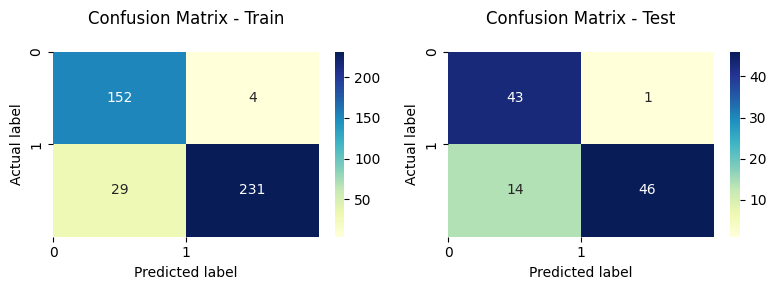

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

class_names = [0, 1]

# Create one figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# ---- Train Confusion Matrix ----
sns.heatmap(pd.DataFrame(cnf_matrix_train),
            annot=True, cmap="YlGnBu", fmt='g',
            ax=axes[0])

axes[0].set_title('Confusion Matrix - Train', pad=20)
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('Actual label')
axes[0].set_xticks(np.arange(len(class_names)))
axes[0].set_yticks(np.arange(len(class_names)))
axes[0].set_xticklabels(class_names)
axes[0].set_yticklabels(class_names)

# ---- Test Confusion Matrix ----
sns.heatmap(pd.DataFrame(cnf_matrix),
            annot=True, cmap="YlGnBu", fmt='g',
            ax=axes[1])

axes[1].set_title('Confusion Matrix - Test', pad=20)
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('Actual label')
axes[1].set_xticks(np.arange(len(class_names)))
axes[1].set_yticks(np.arange(len(class_names)))
axes[1].set_xticklabels(class_names)
axes[1].set_yticklabels(class_names)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---- TRAIN METRICS ----
train_accuracy = accuracy_score(y_train, y_pred_train)
train_precision = precision_score(y_train, y_pred_train)
train_recall = recall_score(y_train, y_pred_train)
train_f1 = f1_score(y_train, y_pred_train)

# ---- TEST METRICS ----
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

# ---- CREATE DATAFRAME ----
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Train': [train_accuracy, train_precision, train_recall, train_f1],
    'Test': [test_accuracy, test_precision, test_recall, test_f1]
})

# Optional: round values
metrics_df[['Train', 'Test']] = metrics_df[['Train', 'Test']].round(4)

metrics_df.T

,0,1,2,3
Metric,Accuracy,Precision,Recall,F1 Score
Train,0.9207,0.983,0.8885,0.9333
Test,0.8558,0.9787,0.7667,0.8598


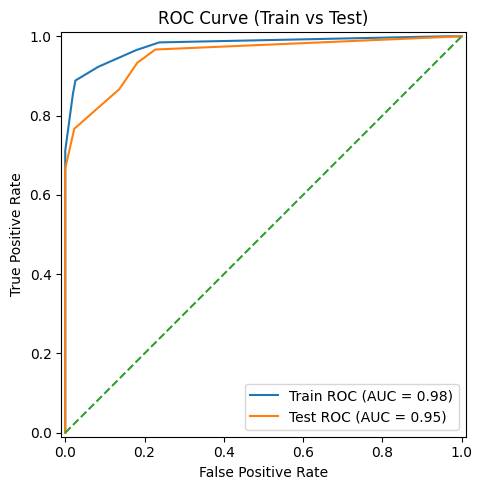

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Predicted probabilities
y_train_proba = dt.predict_proba(X_train)[:, 1]
y_test_proba = dt.predict_proba(X_test)[:, 1]

# Create one figure
fig, ax = plt.subplots(figsize=(7,5))

# Plot ROC for TRAIN
RocCurveDisplay.from_predictions(
    y_train, y_train_proba,
    name="Train ROC",
    ax=ax
)

# Plot ROC for TEST
RocCurveDisplay.from_predictions(
    y_test, y_test_proba,
    name="Test ROC",
    ax=ax
)

# Diagonal reference line
ax.plot([0, 1], [0, 1], linestyle='--')

# Labels & title
ax.set_title("ROC Curve (Train vs Test)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

plt.tight_layout()
plt.show()

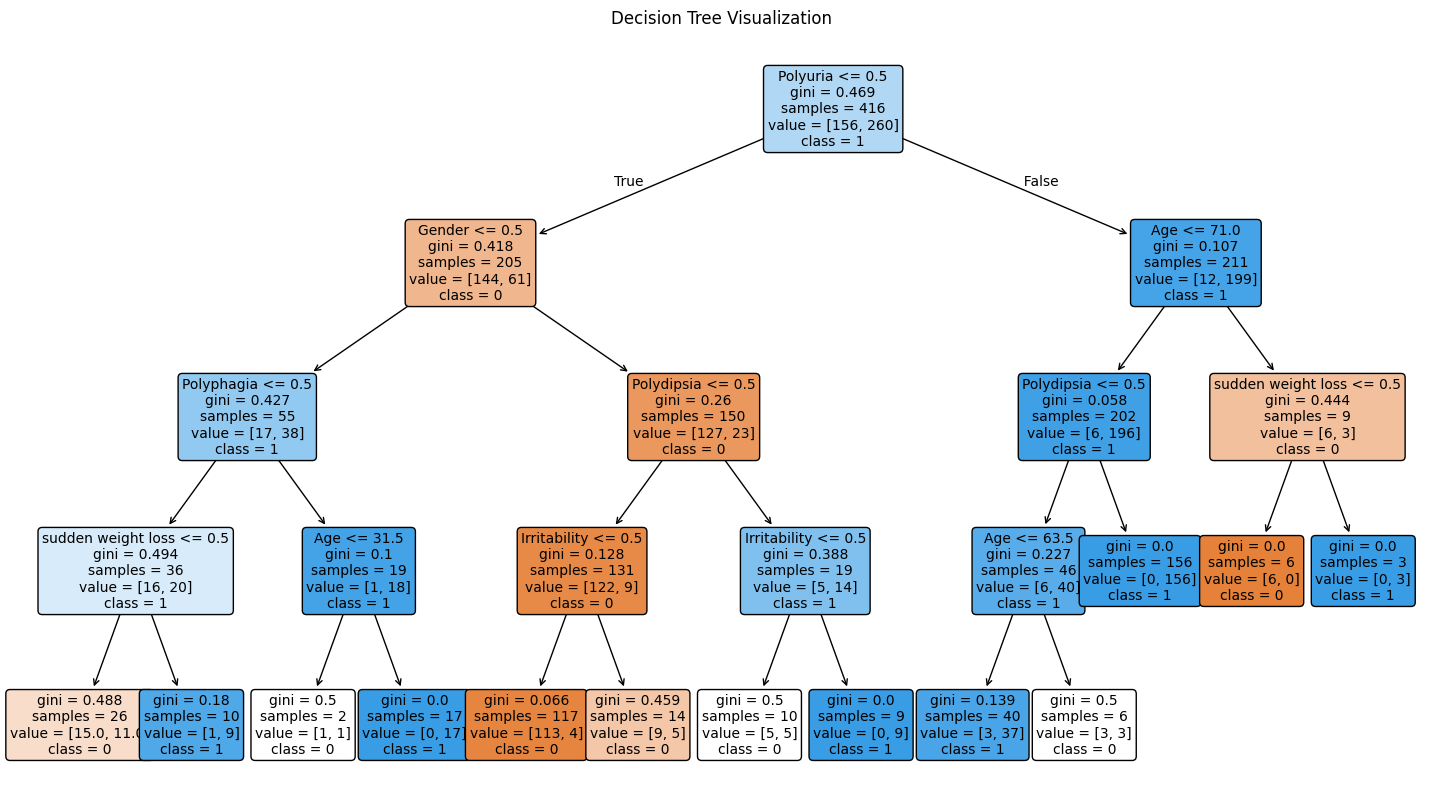

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    dt,
    feature_names=X_train.columns,   # if X_train is a DataFrame
    class_names=[str(c) for c in dt.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Visualization")
plt.show()

In [ ]:
from sklearn.tree import export_text

tree_rules = export_text(dt, feature_names=list(X_train.columns))
print(tree_rules)

|--- Polyuria <= 0.50
|   |--- Gender <= 0.50
|   |   |--- Polyphagia <= 0.50
|   |   |   |--- sudden weight loss <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- sudden weight loss >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Polyphagia >  0.50
|   |   |   |--- Age <= 31.50
|   |   |   |   |--- class: 0
|   |   |   |--- Age >  31.50
|   |   |   |   |--- class: 1
|   |--- Gender >  0.50
|   |   |--- Polydipsia <= 0.50
|   |   |   |--- Irritability <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Irritability >  0.50
|   |   |   |   |--- class: 0
|   |   |--- Polydipsia >  0.50
|   |   |   |--- Irritability <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Irritability >  0.50
|   |   |   |   |--- class: 1
|--- Polyuria >  0.50
|   |--- Age <= 71.00
|   |   |--- Polydipsia <= 0.50
|   |   |   |--- Age <= 63.50
|   |   |   |   |--- class: 1
|   |   |   |--- Age >  63.50
|   |   |   |   |--- class: 0
|   |   |--- Polydipsia >  0.50
|   |   |   |--- class: 1
|   |---

In [ ]:
print("Tree Depth:", dt.get_depth())
print("Number of Leaves:", dt.get_n_leaves())
print("Number of Features:", dt.n_features_in_)

Tree Depth: 4
Number of Leaves: 13
Number of Features: 9
